In [1]:
import logging
# Let's disable all the annoying messages from PySME
logging.disable(logging.WARNING)
import warnings
warnings.filterwarnings(action="ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", module="pysme.synthesize")
# from astropy.utils.exceptions import AstropyWarning
# warnings.filterwarnings(action="ignore", category=AstropyWarning)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
np.set_printoptions(suppress=True, precision=6)
from astropy.io import fits

In [2]:
%load_ext autoreload
%autoreload 2
from pysme_wrapper import *
from pysme_wrapper.utils import *

/home/paramre/miniforge3/envs/sme/lib/python3.12/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/paramre/miniforge3/envs/sme/lib/python3.12/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [3]:
from scipy.interpolate import interp1d
class ferosSpec:
    def __init__(self, file_path):
        with fits.open(file_path) as hdul:
            self.header         = hdul[0].header
            self.Norder = len(hdul[1].data)
            self.echelle = {
                'wavelength': hdul[1].data,
                'flux': hdul[2].data,
                'flux_err': hdul[3].data,
                'flux_norm': hdul[4].data,
                'flux_norm_err': hdul[5].data,
                'flux_cnorm': hdul[6].data,
                'flux_cnorm_err': hdul[7].data,
                'flux_continuum': hdul[8].data,
                'snr': hdul[9].data}

            self.wavelength = hdul[12].data
            self.flux = hdul[13].data
            self.weight = hdul[14].data
            self.merged_spec = hdul[15].data
            self.wranblaze = np.vstack([[self.echelle['wavelength'][i,[0,-1]] for i in range(self.Norder)]])[-1::-1]
            epts = self.wranblaze.ravel()[1:-1].reshape([-1,2]).mean(1)
            epts = np.repeat(epts,2)
            self.wranblaze = np.insert(epts, [0,len(epts)], self.wranblaze.ravel()[[0,-1]]).reshape([-1,2])

            self.getR = self.create_global_R_interpolant()

    def create_global_R_interpolant(self):  
        gridres=0.03
        waveord = self.echelle['wavelength']
        # Create a fine grid spanning the global wavelength range.
        wave_grid = np.arange(waveord.min(), waveord.max()+gridres, gridres)
        Rgrid = np.zeros([len(waveord),len(wave_grid)])
        
        # Evaluate R at each grid point from each order
        for i, wave in enumerate(waveord):
            # Create interpolator; points outside the range return NaN.
            R = np.zeros(len(wave)); R[1:] = wave[1:]/(np.diff(wave)*2.2); R[0] = R[1]
            fR = interp1d(wave, R, kind='linear', bounds_error=False, fill_value=np.nan)
            Rgrid[i] = fR(wave_grid)
        
        #  Combine them    
        Ngp = np.isfinite(Rgrid).sum(0)
        c1 = Ngp==1
        c2 = Ngp==2
        c3 = Ngp>2
        Rcomb = np.zeros(len(wave_grid))
        Rcomb[c1|c3] = np.nanmedian(Rgrid[:,c1|c3], axis=0)
        Rcomb[c2] = np.nanmin(Rgrid[:,c2], axis=0)
        
        # Create a global interpolant object from the computed grid.
        global_R_interpolant = interp1d(wave_grid, Rcomb, kind='linear', bounds_error=True)
        return global_R_interpolant        

class feroscoaddSpec:
    def __init__(self, Specs):
        self.Nspec = len(Specs)
        for i in range(len(Specs)):
            if (Specs[i].wavelength != Specs[i-1].wavelength).any():
              raise Exception(f"Wavelength grid {i} doesn't match") 
            # c = sigma_clip(Specs[i].weight, stdfunc='mad_std', sigma=5).mask
            # Specs[i].weight[c] = 0
        self.wavelength = Specs[0].wavelength
        self.weight = np.sum([spec.weight for spec in Specs], axis=0)
        self.flux = np.sum([spec.weight*spec.flux for spec in Specs], axis=0)/self.weight
        self.merged_spec = np.sum([spec.weight*spec.merged_spec for spec in Specs], axis=0)/self.weight
        self.Norder = Specs[0].Norder
        self.wranblaze = Specs[0].wranblaze
        self.getR = Specs[0].getR

In [4]:
spec = feroscoaddSpec([ferosSpec('Gaia_DR3_3208829887146528384_A_sp.fits'), ferosSpec('Gaia_DR3_3208829887146528384_B_sp.fits')])

In [5]:
import pickle
dr3id = 3208829887146528384
with open('/home/paramre/Param/AMRF/FEROS_2025/results_teff_vmic_feh_vsini_fixedlogg.pkl','rb') as file:
    teff, vmic, feh, vsini, *_ = pickle.load(file)[dr3id]

import astropy.table as tabl
amrf = tabl.Table.read('/home/paramre/Param/AMRF/AMRF_Andrae23_Zhang23_Bayestar19_Lallement19_score_valid.fits')
idx = (amrf['source_id']==dr3id).nonzero()[0][0]
logg = amrf['logg_xgboost'][idx]

In [6]:
balines = np.array([4554.03, 5853.68, 6496.9]) 
rv = 215

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(spec.wavelength, spec.merged_spec)
plt.tight_layout()

for line in balines:
    plt.axvline(line*(1+rv/3e5), color='k')

---

## Stellar params

In [7]:
sme = SMEwrapper()
sme.input_observed_spectrum(wave=spec.wavelength, flux=spec.merged_spec, res=spec.getR(spec.wavelength)) 

# Fixed parameters
sme.logg = logg
sme.teff = teff
sme.monh = feh
sme.vmac = 0
sme.vsini = vsini
sme.vmic = vmic

# tellurics
h = fits.open('3208829887146528384B.fits')[0].header
lat = h['ESO TEL GEOLAT']
alt = h['ESO TEL GEOELEV']
temp = h['ESO TEL AMBI TEMP']
press = (h['ESO TEL AMBI pres start'] + h['ESO TEL AMBI pres end'])/2
hum = h['ESO TEL AMBI RHUM']
airmass = h['AIRMASS']
sme.get_telluric_transmission(lat=lat, alt=alt, temperature=temp, pressure=press, humidity=hum, airmass=airmass, resolution=48000, inair=True, nan_thresh=0.98)

### Select Fe lines

In [ ]:
# First set a line depth threshold
ldthresh = 0.4
wrantry = create_ranges(vald.wlcent[(vald.element=='Fe') & (vald.depth>=ldthresh/2) & inranges(vald.wlcent, [4500,6700])], halfspan=0.025, join=True)
trylinelist = vald[(vald.element=='Fe') & inranges(vald.wlcent, wrantry)]
smetry = initsme(linelist=trylinelist, res=48000, teff=5250, logg=4.5, vsini=5.5, nlteelems=[])

# Synthesize for wrantry
WAVE, SYN = fast_synthesize(smetry, wrantry, delta_lambda=0.003, linelist=trylinelist)
wranother = create_ranges(wrantry.mean(1), halfspan=0.5, join=False) # Join is False here to maintain separate ranges for each line, which is important for the next step.
otherlinelist = vald[(vald.element!='Fe') & inranges(vald.wlcent, combine_ranges(wranother)) & (vald.depth>ldthresh/20)]

# Synthesize for wranother
smeoth = initsme(linelist=otherlinelist, res=48000, teff=5250, logg=4.5, vsini=5.5, nlteelems=[]) # Same stellar parameters as before; NLTE is not needed for this crude measure.
WAVEOTH, SYNOTH = fast_synthesize(smeoth, wranother, delta_lambda=0.003, linelist=otherlinelist)

In [ ]:
cin1,cin2 = np.ones([2,len(wrantry)], bool)
linedepths = np.array([1 - SYN[i].min() for i in range(len(wrantry))])
othdepths = np.array([1 - SYNOTH[i].min() for i in range(len(wrantry))])
cin1 = (linedepths>ldthresh) 
cin2 = (othdepths<(0.2*linedepths))
# Additional filters here...
wcen = wrantry.mean(1)[cin1&cin2]
linedepths = linedepths[cin1&cin2]
othdepths = othdepths[cin1&cin2]
print(f'No of segments: {len(linedepths)}')

### Preliminary RV estimate
Now you need a preliminary RV estimate to shift the line centers to the observed spectrum. You can do this by fitting any prominent line(s) like H-α or Mg-b.

In [ ]:
RV = sme.fit_RV(approx_resolution=48000, window_size=40, wave_locations=[6563], linelist=vald[vald.element=='H']) # H-α region
RV = np.mean(RV) # If you fit multiple lines, take the mean RV.
print(RV)

In [ ]:
plt.figure(figsize=(15,3))
# plt.plot(sme.wave[0], sme.spec[0])
# plt.plot(sme.wave[0], sme.synth[0])
c = inranges(sme.obswave, [6550, 6577])
plt.plot(sme.obswave[c], sme.obsflux[c])
plt.axvline(6562.8*(1+RV/299792.5), c='k')
plt.tight_layout()

In [ ]:
## Next, you can to remove lines affected by telluric features, nans, poor RV estimate, or other issues in your observed spectrum.
# First simply remove those with nans or telluric features in unfortunate locations
# For ex:
core_ranges = create_ranges(wcen, halfspan=0.2, join=False)
extended_ranges = create_ranges(wcen, halfspan=20, join=False)
wave = sme.obswave*(1-RV/299792.5)

cincore, cinext = np.ones([2,len(wcen)], bool)
for i in range(len(wcen)):
    # cut if any line core nans
    coreflux = sme.obsflux[inranges(wave, core_ranges[i])]
    if np.isnan(coreflux).any():
        cincore[i] = False
    # cut if more than 25% nans in extended region used
    extflux = sme.obsflux[inranges(wave, extended_ranges[i])]
    if (np.isnan(extflux).sum()/extflux.size) > 0.25:
        cinext[i] = False

wcen = wcen[cincore & cinext]
linedepths = linedepths[cincore & cinext] # Maintain a record of the linedepths for future filtering if wanted.
print(f'No of segments: {len(wcen)}')

In [ ]:
# Let's filter the lines a bit
cbest = np.argsort(linedepths)[-1:-61:-1]
wcen = wcen[cbest]
linedepths = linedepths[cbest]
# Re-sort
sortidx = np.argsort(wcen)
wcen = wcen[sortidx]
linedepths = linedepths[sortidx]
print(f'No of segments: {len(wcen)}')

### Make fitting segments

In [ ]:
sme.WRAN = create_ranges(wcen, halfspan=0.5, join=True) # join MUST be True here for the next steps to work properly.
print(f'No of segments: {sme.NSEG}')

In [ ]:
sme.make_fit_segments()

In [ ]:
sme.save_fit_segments('gaia_fit_segments.npz')

In [8]:
sme.load_fit_segments('gaia_fit_segments.npz')

In [10]:
sme.NSEG

45

In [11]:
# Lets keep the 20 segments with the highest SNR
sme.delete_fit_segments(sme.ERR.argsort()[20:])
print(sme.NSEG)

20


In [12]:
sme.nlte.set_nlte('Fe')

In [13]:
teff, feh, vsini, vmic

(5438.883207386013, -0.7656696582614353, 3.93178213912108, 0.5539204819127146)

In [ ]:
create_mcmc_grid(sme, {'teff': np.arange(5200,5800,100), 'monh': np.arange(-1,-0.3,0.1)}, delta_lambda=0.003, filename='gaia_teff_monh_grid', nprocesses=8, return_grid=False)

In [15]:
mcobj1 = MCMCsetup(sme, grids='gaia_teff_monh_grid.npz', vsini_grid=[0,6], nprocesses=8)
sampler1 = mcobj1.run_mcmc(nsteps=1750)

100%|██████████| 1750/1750 [01:11<00:00, 24.40it/s]


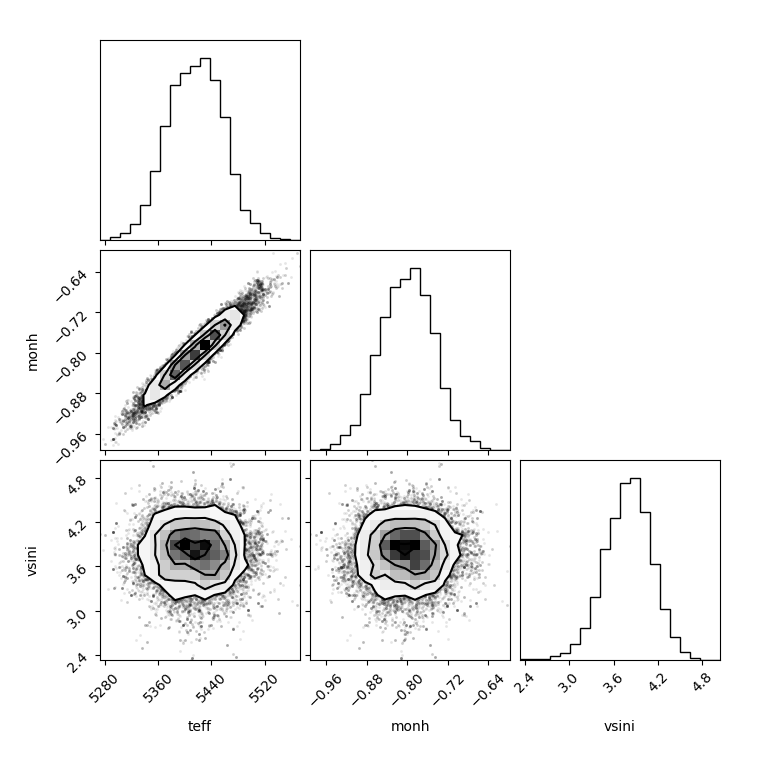

In [16]:
samples = sampler1.get_chain(discard=500, thin=1, flat=True)
import corner
labels = ['teff', 'monh', 'vsini']
corner.corner(samples, labels=labels)
plt.show()

## Ba

In [ ]:
sme = SMEwrapper()
sme.input_observed_spectrum(wave=spec.wavelength, flux=spec.merged_spec, res=spec.getR(spec.wavelength)) 

# Fixed parameters
sme.logg = logg
sme.teff = teff
sme.monh = feh
sme.vmac = 0
sme.vsini = vsini
sme.vmic = vmic

In [ ]:
sme.WRAN = create_ranges(balines, halfspan=0.5, join=True)
print(f'No of segments: {sme.NSEG}')

In [ ]:
sme.make_fit_segments(RV='fit',CS='fit',ERR='fit',make_quality_cuts=False)

In [ ]:
sme.nlte.set_nlte('Ba')

In [ ]:
mcobj = MCMCsetup(sme, grids={'abund Ba':np.arange(0, 4.01, 0.1)}, nprocesses=8)

In [ ]:
%matplotlib widget

In [ ]:
from brokenaxes import brokenaxes

plt.figure(figsize=(10, 6))
baxes = brokenaxes(
    xlims=[(w.min(), w.max()) for w in mcobj.wavegrid],
    hspace=0.5
)

x = np.hstack(mcobj.wavegrid)
for syn in mcobj.syngrid:
    baxes.plot(x, syn, 'k-', alpha=0.2)

baxes.plot(np.hstack(sme.WAVE), np.hstack(sme.FLUX), color='C0')
plt.show()

In [ ]:
sampler = mcobj.run_mcmc(nsteps=1500)

In [ ]:
samples = sampler.get_chain(discard=500, thin=1, flat=True).squeeze()
plt.figure()
plt.hist(samples)
# import corner
# labels = ['ba', 'vmic', 'vsini']
# corner.corner(samples, labels=labels)
# plt.show()